# WiniCari — AI Layer EDA

In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

from src.data.db import client

In [2]:
from src.data.db import get_db

db_winicari = get_db("winicari")
db_gps = get_db("Historique_pos")

## Map the database landscape

In [3]:
import pandas as pd

SYSTEM = {"admin", "config", "local"}

all_dbs = client.list_database_names()
print("All databases:", all_dbs)

rows = []

for name in all_dbs:
    if name in SYSTEM:
        continue
    n_collections = len(client[name].list_collection_names())
    rows.append({
        "database": name,
        "n_collections": n_collections
    })

landscape = pd.DataFrame(rows)
landscape

All databases: ['Historique_pos', 'admin', 'config', 'local', 'winicari']


,database,n_collections
0,Historique_pos,1603
1,winicari,55


In [4]:
# winicari — collection inventory (estimated counts, no full scan)
inv = []

for col in db_winicari.list_collection_names():
    count = db_winicari[col].estimated_document_count()
    inv.append({
        "collection": col,
        "est_count": count
    })

winicari_inv = pd.DataFrame(inv)
winicari_inv = winicari_inv.sort_values(
    by="est_count",
    ascending=False
).reset_index(drop=True)

print("Number of collections:", len(winicari_inv))
print("Non-empty collections:", (winicari_inv["est_count"] > 0).sum())
print("Total estimated documents:", winicari_inv["est_count"].sum())

winicari_inv

Number of collections: 55
Non-empty collections: 43
Total estimated documents: 214099


,collection,est_count
0,position,64431
1,price,51660
2,details_OLD,25306
3,session_ouverte,15027
4,ticket,13401
5,facebook,10830
6,ConfirmationToken,10292
7,details,7881
8,klm,3331
9,Names,1788


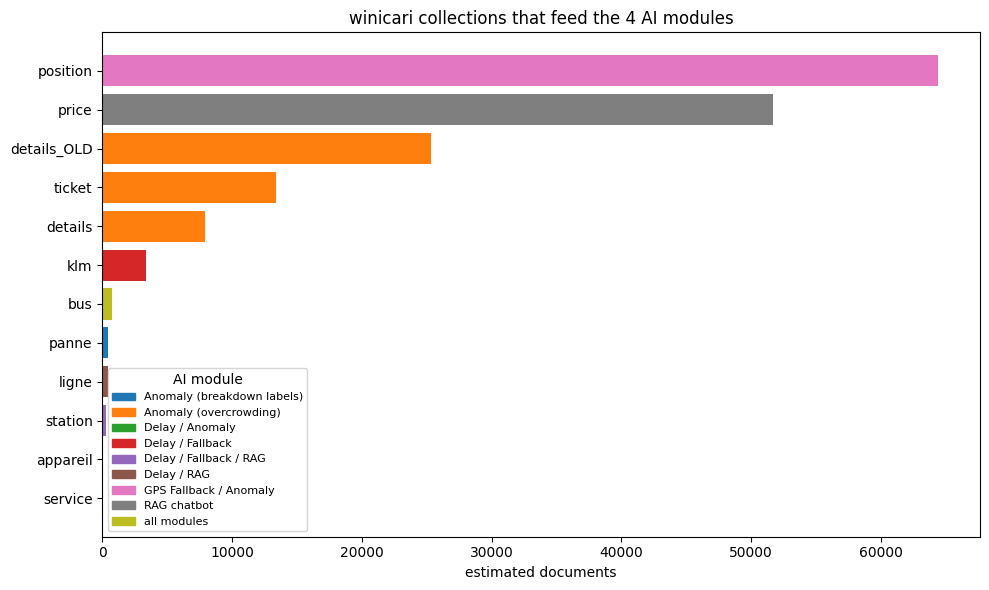

In [5]:
import matplotlib.pyplot as plt

# Which collections feed which AI module (the ones that matter for this project)
module_of = {
    "position":    "GPS Fallback / Anomaly",
    "service":     "Delay / Anomaly",
    "ligne":       "Delay / RAG",
    "station":     "Delay / Fallback / RAG",
    "klm":         "Delay / Fallback",
    "price":       "RAG chatbot",
    "ticket":      "Anomaly (overcrowding)",
    "details":     "Anomaly (overcrowding)",
    "details_OLD": "Anomaly (overcrowding)",
    "panne":       "Anomaly (breakdown labels)",
    "bus":         "all modules",
    "appareil":    "all modules",
}

# Build a small frame of just the module-relevant collections
key = winicari_inv[winicari_inv["collection"].isin(module_of)].copy()
key["module"] = key["collection"].map(module_of)
key = key.sort_values("est_count", ascending=True)

# One colour per module
modules = sorted(key["module"].unique())
palette = dict(zip(modules, plt.cm.tab10.colors))
bar_colors = [palette[m] for m in key["module"]]

plt.figure(figsize=(10, 6))
plt.barh(key["collection"], key["est_count"], color=bar_colors)
plt.xlabel("estimated documents")
plt.title("winicari collections that feed the 4 AI modules")

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=palette[m]) for m in modules]
plt.legend(legend_handles, modules, title="AI module", fontsize=8)
plt.tight_layout()
plt.show()

## Companies — operation volume vs ridership

Three angles per company (from `details` + `details_OLD`, 2019–2026), plus lines owned:
- **services run** = operating bus-days (one ticketing row ≈ a device selling on a line that day).
- **tickets sold** = total `nbrTicket` — how many passengers actually rode.
- **tickets per service** = tickets ÷ service-days = average ridership per run = an **efficiency / fullness** signal.

> "Services run" measures *operation volume*, not staffing — a high number means a company operates
> a lot, not that it is overstaffed. Ridership (tickets per service) is the better efficiency lens.
> ⚠️ This only counts activity **recorded in WiniCari ticketing**, so a company that operates but
> doesn't use the devices would look inactive here.

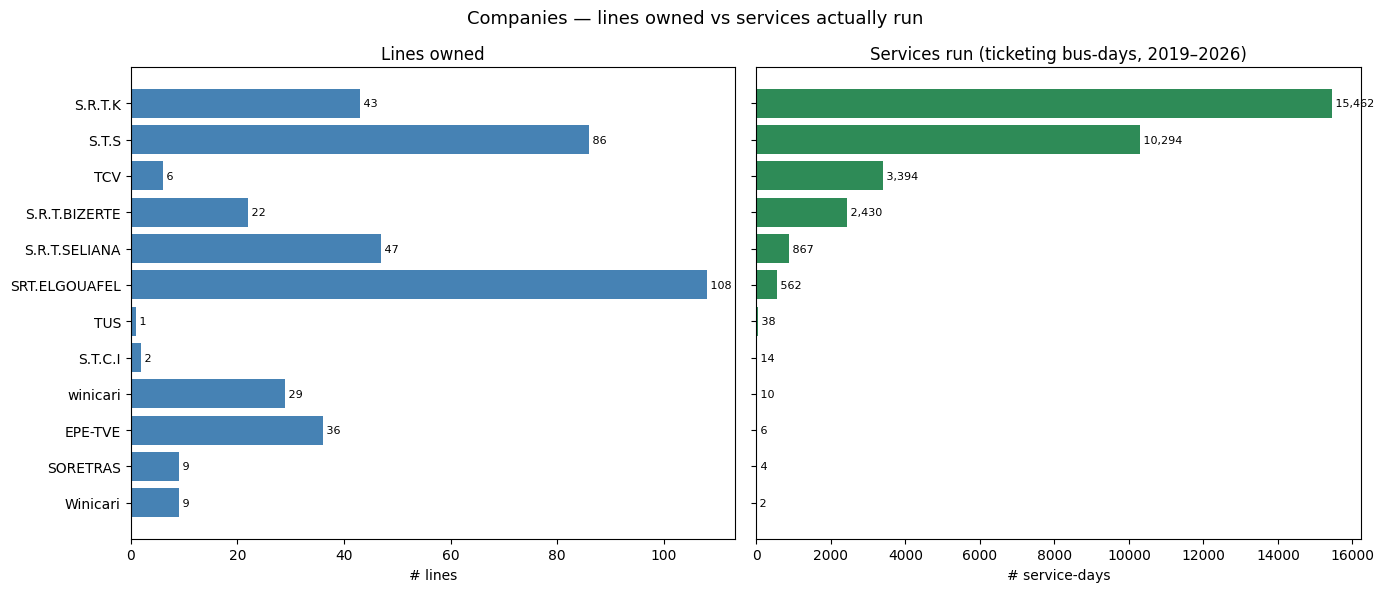

,lines,service_days,tickets,recette,tickets_per_service
S.R.T.K,43,15462,938266,5326921,60.7
S.T.S,86,10294,2809312,2039147,272.9
TCV,6,3394,487501,828784,143.6
S.R.T.BIZERTE,22,2430,126364,280765,52.0
S.R.T.SELIANA,47,867,65389,187541,75.4
SRT.ELGOUAFEL,108,562,32321,331292,57.5
TUS,1,38,1946,4929,51.2
S.T.C.I,2,14,192,4067,13.7
winicari,29,10,27,307,2.7
EPE-TVE,36,6,64,22741,10.7


In [6]:
from IPython.display import display

# lines owned per company (config)
lines_per = pd.Series({d["_id"]: d["n"] for d in db_winicari["ligne"].aggregate(
    [{"$group": {"_id": "$societe", "n": {"$sum": 1}}}])}, name="lines")

# operation volume + ridership per company from ticketing aggregates (2019-2026)
acc = {}
for col in ["details", "details_OLD"]:
    for d in db_winicari[col].aggregate([{"$group": {"_id": "$societe",
            "service_days": {"$sum": 1}, "tickets": {"$sum": "$nbrTicket"}, 
            "recette": {"$sum": "$recette"}}}]):
        if not d["_id"]:
            continue
        a = acc.setdefault(d["_id"], {"service_days": 0, "tickets": 0, "recette": 0})
        a["service_days"] += d["service_days"]
        a["tickets"] += d.get("tickets") or 0
        a["recette"] += d.get("recette") or 0

comp = pd.DataFrame(acc).T
comp["lines"] = lines_per
comp = comp.fillna(0)
comp["tickets_per_service"] = (comp["tickets"] / comp["service_days"].replace(0, pd.NA)).round(1)
comp = comp[["lines", "service_days", "tickets", "recette", "tickets_per_service"]]
comp[["lines", "service_days", "tickets", "recette"]] = comp[["lines", "service_days", "tickets", "recette"]].astype(int)
comp = comp.sort_values("service_days", ascending=True)

# Original lines vs services chart (restored)
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
ax[0].barh(comp.index, comp["lines"], color="steelblue")
ax[0].set_title("Lines owned"); ax[0].set_xlabel("# lines")
for i, v in enumerate(comp["lines"]):
    ax[0].text(v, i, f" {v}", va="center", fontsize=8)

ax[1].barh(comp.index, comp["service_days"], color="seagreen")
ax[1].set_title("Services run (ticketing bus-days, 2019–2026)"); ax[1].set_xlabel("# service-days")
for i, v in enumerate(comp["service_days"]):
    ax[1].text(v, i, f" {v:,}", va="center", fontsize=8)

plt.suptitle("Companies — lines owned vs services actually run", fontsize=13)
plt.tight_layout(); plt.show()

display(comp.sort_values("service_days", ascending=False))

### What this says (is S.R.T.K inefficient?)

- **S.R.T.K is not overstaffed/inefficient — it is the biggest operator.** Most service-days
  *and* the highest revenue (~5.3 M). High "services run" = high operation volume, not staffing.
- **But its ridership per run is low (~61 tickets/bus-day)** — buses run relatively empty,
  consistent with rural lines where people don't ride as much (your own note). So the *efficiency*
  gap is about **how full the buses are**, not how many runs it does.
- **S.T.S is the ridership leader (~273 tickets/run, ~4× S.R.T.K)** — fewer bus-days but 2.8 M
  tickets: full coastal/urban buses. **TCV** (urban shuttle, 6 lines) ~144/run.
- **The other companies genuinely run far less in this system.** SRT.ELGOUAFEL owns 108 lines on
  paper but logs only ~562 bus-days — and it only joined WiniCari in 2024, so little history. So
  yes: *they don't operate as much here* — but remember this counts ticketing activity, not real
  road operation, so light system usage can also explain it.

so srtk 

### Independent charts by metric

isint the ticket window 1 week?


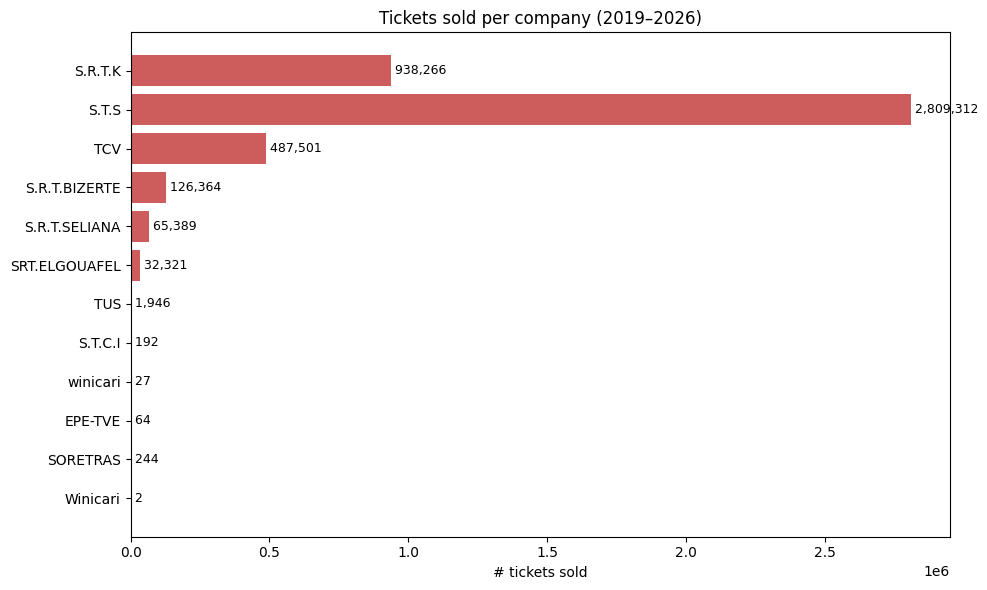

In [7]:
plt.figure(figsize=(10, 6))
plt.barh(comp.index, comp["tickets"], color="indianred")
plt.xlabel("# tickets sold")
plt.title("Tickets sold per company (2019–2026)")
for i, v in enumerate(comp["tickets"]):
    plt.text(v, i, f" {v:,}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

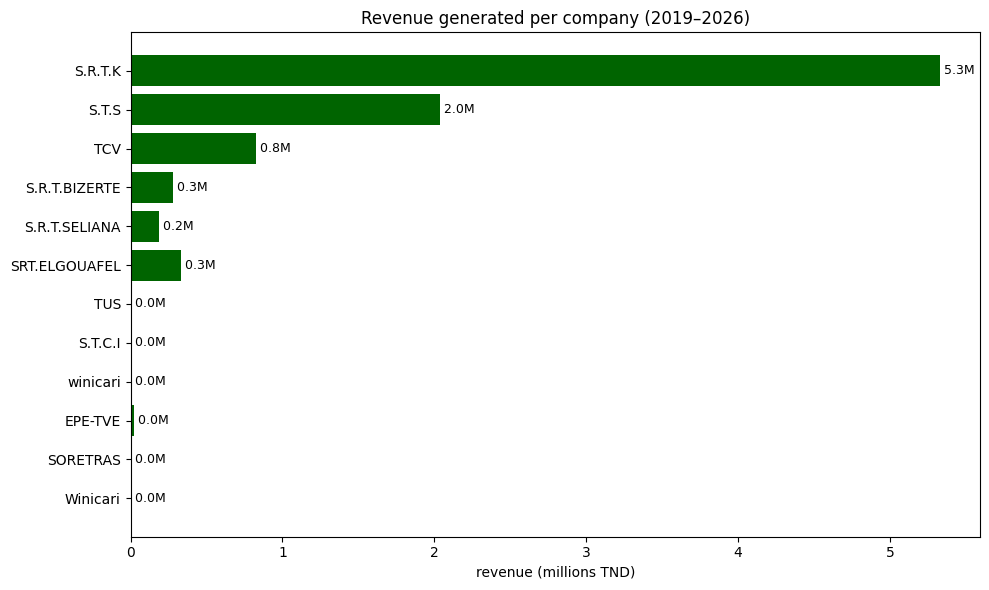

In [8]:
plt.figure(figsize=(10, 6))
plt.barh(comp.index, comp["recette"] / 1e6, color="darkgreen")  # convert to millions
plt.xlabel("revenue (millions TND)")
plt.title("Revenue generated per company (2019–2026)")
for i, v in enumerate(comp["recette"] / 1e6):
    plt.text(v, i, f" {v:.1f}M", va="center", fontsize=9)
plt.tight_layout(); plt.show()

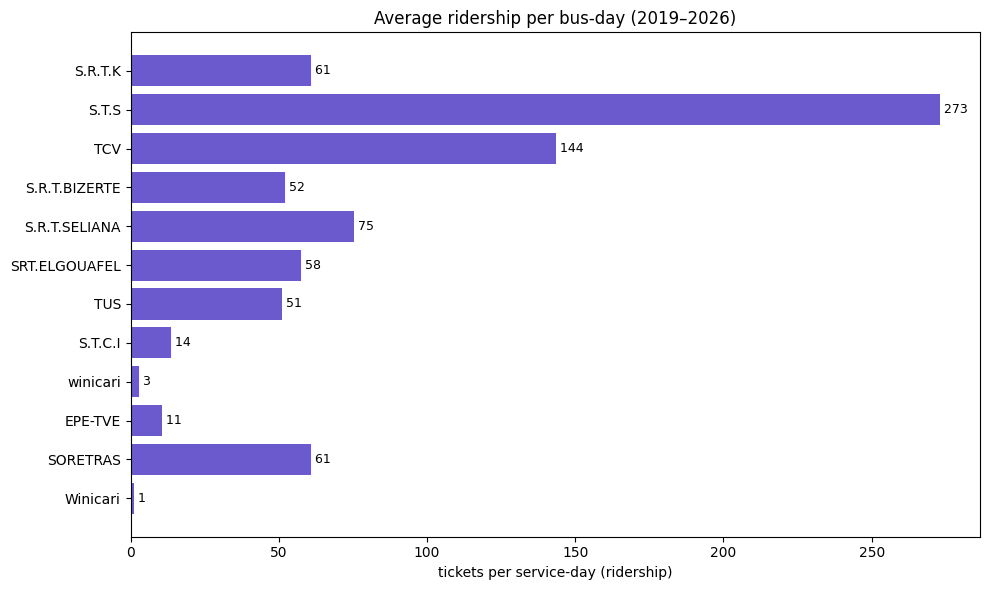

In [9]:
plt.figure(figsize=(10, 6))
plt.barh(comp.index, comp["tickets_per_service"], color="slateblue")
plt.xlabel("tickets per service-day (ridership)")
plt.title("Average ridership per bus-day (2019–2026)")
for i, v in enumerate(comp["tickets_per_service"]):
    plt.text(v, i, f" {v:.0f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

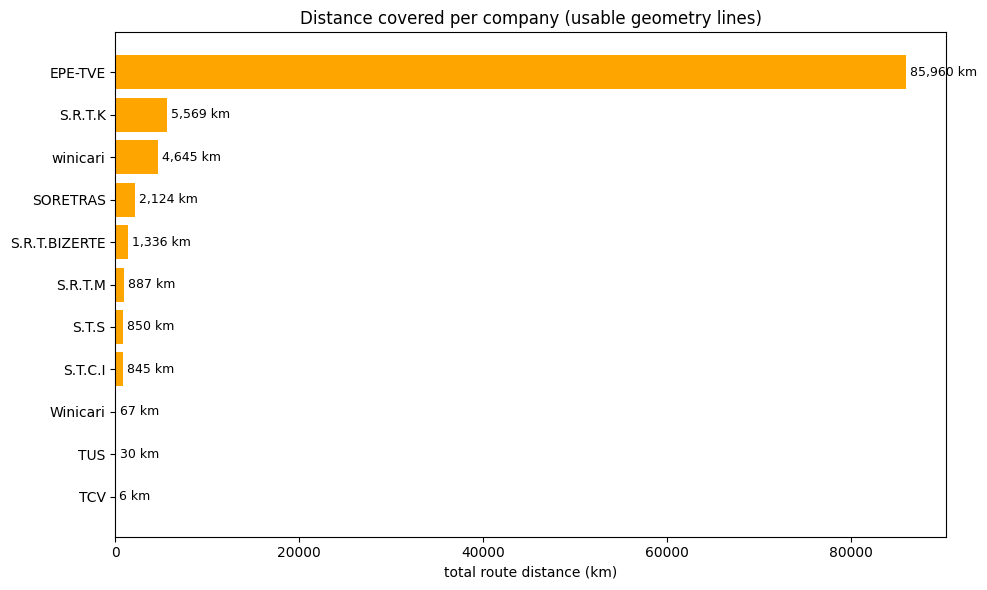

,lines,total_km
EPE-TVE,35.0,85959.640070
S.R.T.K,29.0,5569.321277
winicari,26.0,4644.891686
SORETRAS,9.0,2123.808358
S.R.T.BIZERTE,13.0,1335.840807
S.R.T.M,2.0,886.882150
S.T.S,15.0,850.084237
S.T.C.I,2.0,845.340949
Winicari,2.0,67.166855
TUS,1.0,30.455337


In [10]:
from src.data import foundation as fdn

cfg = fdn.Config()
usable = fdn.build_usable_lines(db_winicari, cfg)
dist = {}
for (code, soc), stops in usable.items():
    if soc not in dist:
        dist[soc] = {'lines': 0, 'total_km': 0.0}
    dist[soc]['lines'] += 1
    dist[soc]['total_km'] += stops['s_m'].max() / 1000.0

dist_df = pd.DataFrame(dist).T.sort_values('total_km', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(dist_df.index, dist_df['total_km'], color="orange")
plt.xlabel("total route distance (km)")
plt.title("Distance covered per company (usable geometry lines)")
for i, v in enumerate(dist_df['total_km']):
    plt.text(v, i, f" {v:,.0f} km", va="center", fontsize=9)
plt.tight_layout(); plt.show()

display(dist_df.sort_values('total_km', ascending=False))

In [11]:
import re
from datetime import date

gps_cols = []
for c in db_gps.list_collection_names():
    if re.fullmatch(r"d\d{8}", c):
        gps_cols.append(c)
gps_cols = sorted(gps_cols)

counts = {}
days = []
for c in gps_cols:
    counts[c] = db_gps[c].estimated_document_count()
    day = date(int(c[1:5]), int(c[5:7]), int(c[7:9]))
    days.append(day)

total = sum(counts.values())

print("Daily GPS collections:",len(gps_cols))
print("Date range:", days[0], "->", days[-1])
print("Total pings (est):",total)
print("Pings/day min/avg/max:", min(counts.values()), "/", total // len(gps_cols), "/", max(counts.values()))

# missing-day gaps
print("\nMissing-day gaps:")
for i in range(1, len(days)):
    diff = (days[i] - days[i-1]).days
    if diff > 1:
        print("   ", days[i-1], "->", days[i], "(", diff - 1, "days missing )")

Daily GPS collections: 1603
Date range: 2022-01-21 -> 2026-06-21
Total pings (est): 36346673
Pings/day min/avg/max: 1 / 22674 / 122413

Missing-day gaps:
    2025-01-11 -> 2025-01-18 ( 6 days missing )
    2025-06-05 -> 2025-06-07 ( 1 days missing )
    2025-08-23 -> 2025-08-25 ( 1 days missing )
    2026-03-27 -> 2026-03-30 ( 2 days missing )


In [12]:
print(gps_cols)

['d20220121', 'd20220122', 'd20220123', 'd20220124', 'd20220125', 'd20220126', 'd20220127', 'd20220128', 'd20220129', 'd20220130', 'd20220131', 'd20220201', 'd20220202', 'd20220203', 'd20220204', 'd20220205', 'd20220206', 'd20220207', 'd20220208', 'd20220209', 'd20220210', 'd20220211', 'd20220212', 'd20220213', 'd20220214', 'd20220215', 'd20220216', 'd20220217', 'd20220218', 'd20220219', 'd20220220', 'd20220221', 'd20220222', 'd20220223', 'd20220224', 'd20220225', 'd20220226', 'd20220227', 'd20220228', 'd20220301', 'd20220302', 'd20220303', 'd20220304', 'd20220305', 'd20220306', 'd20220307', 'd20220308', 'd20220309', 'd20220310', 'd20220311', 'd20220312', 'd20220313', 'd20220314', 'd20220315', 'd20220316', 'd20220317', 'd20220318', 'd20220319', 'd20220320', 'd20220321', 'd20220322', 'd20220323', 'd20220324', 'd20220325', 'd20220326', 'd20220327', 'd20220328', 'd20220329', 'd20220330', 'd20220331', 'd20220401', 'd20220402', 'd20220403', 'd20220404', 'd20220405', 'd20220406', 'd20220407'

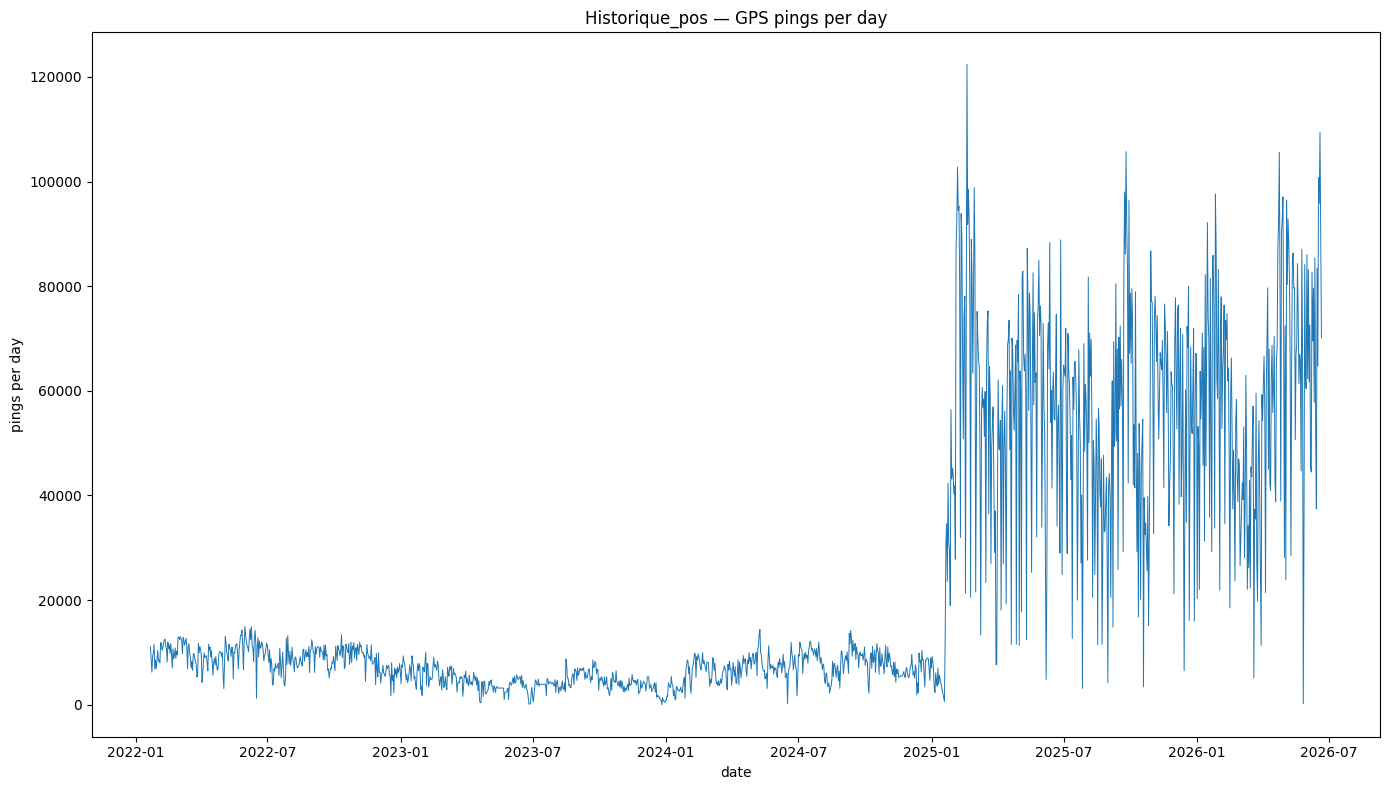

In [13]:
plt.figure(figsize=(14, 8))
plt.plot(days, [counts[c] for c in gps_cols], linewidth=0.7)
plt.ylabel("pings per day")
plt.xlabel("date")
plt.title("Historique_pos — GPS pings per day")
plt.tight_layout()
plt.show()

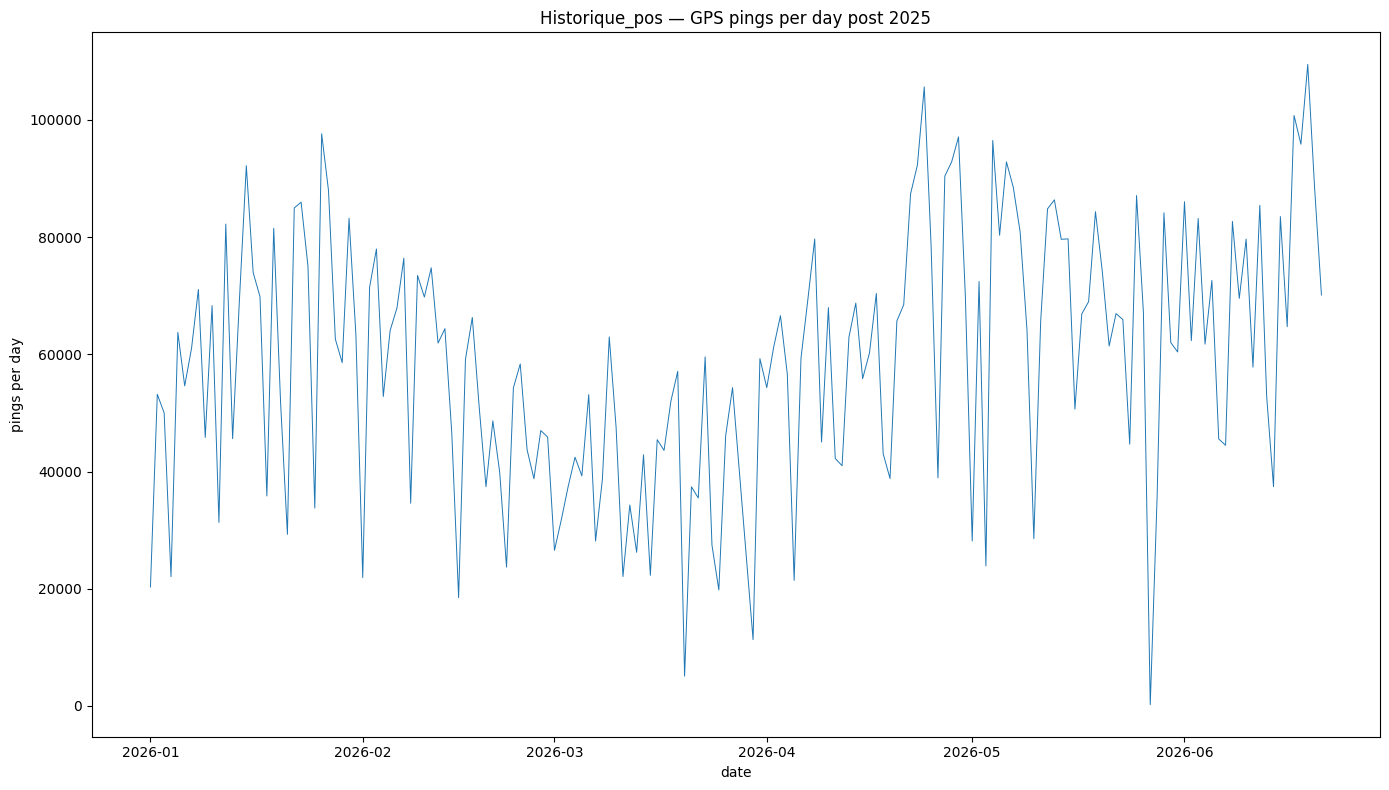

In [14]:
post2025 = [c for c in gps_cols if c > "d20251231"]
days_post2025 = []
for c in post2025:
    counts[c] = db_gps[c].estimated_document_count()
    day = date(int(c[1:5]), int(c[5:7]), int(c[7:9]))
    days_post2025.append(day)
plt.figure(figsize=(14, 8))
plt.plot(days_post2025, [counts[c] for c in post2025], linewidth=0.7)
plt.ylabel("pings per day")
plt.xlabel("date")
plt.title("Historique_pos — GPS pings per day post 2025")
plt.tight_layout()
plt.show()

In [15]:
daily = pd.DataFrame({"day": days, "pings": [counts[c] for c in gps_cols]})
daily["year"] = pd.to_datetime(daily["day"]).dt.year

yearly = daily.groupby("year").agg(
    days_with_data=("pings", "size"),
    total_pings=("pings", "sum"),
    avg_pings_per_day=("pings", "mean"),
).reset_index()
yearly["avg_pings_per_day"] = yearly["avg_pings_per_day"].round().astype(int)
yearly

,year,days_with_data,total_pings,avg_pings_per_day
0,2022,345,3178248,9212
1,2023,365,1603992,4394
2,2024,366,2638244,7208
3,2025,357,18901844,52946
4,2026,170,10024345,58967


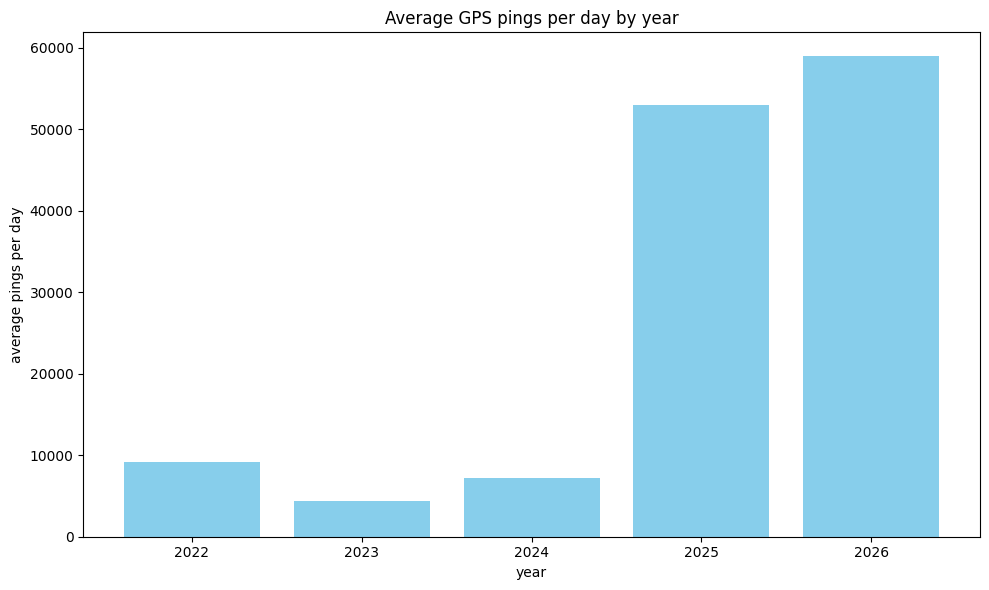

In [16]:
#graph the avrage pings per day by year
plt.figure(figsize=(10, 6))
plt.bar(yearly["year"], yearly["avg_pings_per_day"], color="skyblue")
plt.xlabel("year")
plt.ylabel("average pings per day")
plt.title("Average GPS pings per day by year")
plt.tight_layout()
plt.show()


## Understand each collection

In [17]:
from collections import defaultdict
from IPython.display import display

def profile_collection(db, name, sample=300):
    # Sample docs and report, per field: % present, % null, type(s), an example value.
    coll = db[name]
    n_total = coll.estimated_document_count()
    if n_total == 0:
        print("---", name, "(empty) ---")
        return pd.DataFrame()
    docs = list(coll.aggregate([{"$sample": {"size": min(sample, n_total)}}]))
    n = len(docs)

    fields = defaultdict(lambda: {"present": 0, "null": 0, "types": set(), "example": None})
    for d in docs:
        for k, v in d.items():
            f = fields[k]
            f["present"] += 1
            if v is None:
                f["null"] += 1
            else:
                f["types"].add(type(v).__name__)
                if f["example"] is None:
                    f["example"] = v

    rows = []
    for k, f in fields.items():
        rows.append({
            "field": k,
            "present_%": round(100 * f["present"] / n),
            "null_%": round(100 * f["null"] / f["present"]),
            "types": ", ".join(sorted(f["types"])) or "null",
            "example": str(f["example"])[:45],
        })
    print("---", db.name + "." + name, "| est_count =", f"{n_total:,}", "| sampled =", n, "---")
    return pd.DataFrame(rows)

In [18]:
# Profile the collections that matter for the AI modules
for col in ["bus", "ligne", "station", "service", "ticket", "panne", "details"]:
    display(profile_collection(db_winicari, col))

--- winicari.bus | est_count = 772 | sampled = 300 ---


,field,present_%,null_%,types,example
0,_id,100,0,ObjectId,6641c2e6b076d90f7ba600ca
1,code,100,0,int,143
2,dateAjout,100,0,str,03/11/2023
3,matricule,100,0,str,200 TU 1551
4,nbrPlace,100,0,str,50
5,societe,100,0,str,TUS
6,vitesseMax,100,0,str,70
7,active,97,0,bool,True
8,localisation,39,2,dict,"{'x': 35.880443, 'y': 10.578792}"
9,localisationancien,28,0,dict,"{'x': 35.87693, 'y': 10.580962}"


--- winicari.ligne | est_count = 402 | sampled = 300 ---


,field,present_%,null_%,types,example
0,_id,100,0,ObjectId,69aa8d4450140000df00200d
1,code,100,0,str,50
2,correspendance,100,0,str,50
3,societe,100,0,str,SRT.ELGOUAFEL
4,nbrstations,100,0,"int, str",9
5,TypeV,100,0,str,N
6,orfr,98,0,str,ERDAYEF
7,orar,98,0,str,الرديف
8,desfr,98,0,str,GAFSA
9,desar,98,0,str,قفصة


--- winicari.station | est_count = 289 | sampled = 289 ---


...

,field,present_%,null_%,types,example
0,_id,100,0,ObjectId,6a33e506de691c0ff0672a81
1,idTicket,100,0,int,446
2,codeLigne,100,0,str,40
3,codeCh,100,0,str,1798
4,codeConv,100,0,str,1691
5,codeCentre,100,0,str,33
6,ligne,100,0,str,
7,nomFR1,100,0,str,Safax
8,nomAR1,100,0,str,صفاقس
9,nomFR2,100,0,str,Gafsa


--- winicari.panne | est_count = 453 | sampled = 300 ---


,field,present_%,null_%,types,example
0,_id,100,0,ObjectId,69f44c648b0a0000be006c95
1,bus,100,0,str,6033
2,chauffeur,100,0,str,5920
3,conv,100,0,str,5971
4,type,100,0,str,
5,nom,100,0,str,OSTICKET
6,codeco,100,0,str,9999
7,nserie,100,0,str,BS-18-0007
8,date,100,0,str,20260501
9,heur,100,0,str,0746


--- winicari.details | est_count = 7,881 | sampled = 300 ---


,field,present_%,null_%,types,example
0,_id,100,0,ObjectId,689d9d212fdf22ea15063822
1,societe,100,2,str,S.R.T.K
2,appareil,100,2,str,BS-18-0008
3,date,100,0,str,2025/08/14
4,codeConv,100,0,str,5915
5,codeCh,100,0,str,5930
6,CodeLigne,100,0,str,217
7,codeCentre,100,0,str,00
8,codeBus,100,0,int,6030
9,nbrTicket,100,0,int,95


### The GPS ping changed shape over time (key finding)

The per-day GPS documents are **not** all the same. Fields were added in different
years. This matters a lot for **GPS Fallback** (where do we read speed?) and
**Delay**

In [19]:
drift_days = ["d20220121", "d20230101", "d20240101", "d20250101",
              "d20250601", "d20260101", "d20260601"]

rows = []
for s in drift_days:
    docs = list(db_gps[s].find().limit(300))
    n = len(docs)
    sp = sum("speed" in d for d in docs)
    sv = sum("service" in d for d in docs)
    di = sum("direction" in d for d in docs)
    rows.append({
        "collection": s,
        "speed_present_%": round(100 * sp / n),
        "service_present_%": round(100 * sv / n),
        "direction_present_%": round(100 * di / n),
        "speed_null_%": round(100 * sum(d.get("speed") is None for d in docs) / sp) if sp else None,
        "direction_null_%": round(100 * sum(d.get("direction") is None for d in docs) / di) if di else None,
    })

gps_drift = pd.DataFrame(rows)
gps_drift

,collection,speed_present_%,service_present_%,direction_present_%,speed_null_%,direction_null_%
0,d20220121,0,0,0,NaN,NaN
1,d20230101,0,100,0,NaN,NaN
2,d20240101,0,100,0,NaN,NaN
3,d20250101,0,100,0,NaN,NaN
4,d20250601,100,100,100,0.0,0.0
5,d20260101,100,100,100,0.0,44.0
6,d20260601,100,100,100,0.0,98.0


**Reading the table**

- `localisation` is `{x: latitude, y: longitude}` in **every** era (confusing naming).
- **Speed**: a top-level `speed` field only appears from **early 2025**. But speed is
  available across the *whole* history via the embedded `bus.vitesse` (computed km/h)
  — so for Fallback, use `bus.vitesse` as the universal source.
- **Route link** (`service.codeLigne`) is present from **~mid-2022** onward (missing
  only the first weeks of 2022) — usable for Delay prediction.
- **`direction` (heading) is unreliable**: null rate swings to **98%** on some 2026
  days. Don't depend on it; recompute bearing from consecutive positions if needed.

## Map collections to the 4 AI modules

For each module: what it needs, where that lives, and whether the data is good
enough today.

In [20]:
readiness = pd.DataFrame([
    ["1. Delay prediction", "GPS pings + route link",      "Historique_pos + service.codeLigne",  "OK (route link from ~2022)"],
    ["1. Delay prediction", "Scheduled times per stop",    "ligne.horaires / station.horaires",   "PARTIAL (71/402 lines have times)"],
    ["1. Delay prediction", "Actual arrival per stop",     "(none) - derive from GPS",            "MISSING -> must engineer"],
    ["2. GPS Fallback",     "ts/lat/lon/speed/bus",        "Historique_pos (bus.vitesse all-era)", "OK"],
    ["2. GPS Fallback",     "Route geometry",              "ligne.array_lat/lng_opendata",        "PARTIAL (192/402 lines)"],
    ["3. Anomaly detection","GPS history (3+ months)",     "Historique_pos (~4.4 years)",         "OK"],
    ["3. Anomaly detection","Breakdown labels",            "panne",                               "WEAK (453 rows, ~3 dense months, no cause)"],
    ["3. Anomaly detection","Overcrowding / ticketing",    "ticket (raw) + details (aggregate)",  "WEAK (raw tickets ~1 week only)"],
    ["4. RAG chatbot",      "Schedules / timetables",      "ligne.horaires / station.horaires",   "PARTIAL"],
    ["4. RAG chatbot",      "Routes, stops, fares (FR/AR)","ligne, station, price",               "OK (bilingual present)"],
], columns=["module", "needs", "source", "status"])
readiness

,module,needs,source,status
0,1. Delay prediction,GPS pings + route link,Historique_pos + service.codeLigne,OK (route link from ~2022)
1,1. Delay prediction,Scheduled times per stop,ligne.horaires / station.horaires,PARTIAL (71/402 lines have times)
2,1. Delay prediction,Actual arrival per stop,(none) - derive from GPS,MISSING -> must engineer
3,2. GPS Fallback,ts/lat/lon/speed/bus,Historique_pos (bus.vitesse all-era),OK
4,2. GPS Fallback,Route geometry,ligne.array_lat/lng_opendata,PARTIAL (192/402 lines)
5,3. Anomaly detection,GPS history (3+ months),Historique_pos (~4.4 years),OK
6,3. Anomaly detection,Breakdown labels,panne,"WEAK (453 rows, ~3 dense months, no cause)"
7,3. Anomaly detection,Overcrowding / ticketing,ticket (raw) + details (aggregate),WEAK (raw tickets ~1 week only)
8,4. RAG chatbot,Schedules / timetables,ligne.horaires / station.horaires,PARTIAL
9,4. RAG chatbot,"Routes, stops, fares (FR/AR)","ligne, station, price",OK (bilingual present)


### Ticketing only 1 week of raw tickets, POC proof-of-concept

We can still see the **demand curve by hour** and build an **overcrowding
proxy** = daily boardings per bus-run ÷ seats. Caveat: this is *total daily boardings*
vs capacity, **not** simultaneous occupancy (true occupancy needs origin/destination
boarding-alighting modelling along the route).

Raw ticket window: 2026-06-16 01:42:00.598000 -> 2026-06-22 13:32:00.842000 | rows: 13401 | buses: 35 | lines: 33 | companies: 5
Mean ticket sales per trip: 26.965656565656566


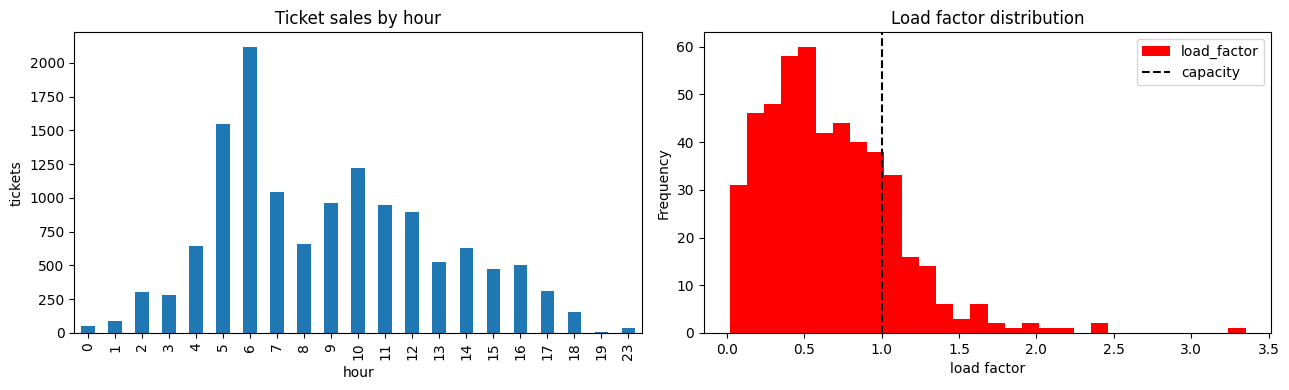

Bus-runs above capacity (load_factor > 1): 88 of 495


In [21]:
tk = pd.DataFrame(list(db_winicari["ticket"].find({}, {
    "idTicket": 1,
    "codeLigne": 1,
    "codeCh": 1,
    "voyage": 1,
    "prix": 1,
    "date": 1,
    "bus.code": 1,
    "bus.nbrPlace": 1,
    "bus.societe": 1,
    "_id": 0
})))

tk["bus_code"] = tk["bus"].apply(lambda b: b.get("code") if isinstance(b, dict) else None)
tk["seats"] = tk["bus"].apply(lambda b: b.get("nbrPlace") if isinstance(b, dict) else None)
tk["societe"] = tk["bus"].apply(lambda b: b.get("societe") if isinstance(b, dict) else None)

tk["seats"] = pd.to_numeric(tk["seats"], errors="coerce")

tk = tk.drop(columns=["bus"])

tk["date"] = pd.to_datetime(tk["date"])
tk["hour"] = tk["date"].dt.hour
tk["day"] = tk["date"].dt.date

print(
    "Raw ticket window:", tk["date"].min(), "->", tk["date"].max(),
    "| rows:", len(tk),
    "| buses:", tk["bus_code"].nunique(),
    "| lines:", tk["codeLigne"].nunique(),
    "| companies:", tk["societe"].nunique()
)

trip = tk.groupby(["bus_code", "day", "codeCh", "voyage"]).agg(
    boardings=("idTicket", "count"),
    seats=("seats", "first"),
    societe=("societe", "first")
).reset_index()

trip["load_factor"] = trip["boardings"] / trip["seats"]

# mean ticket sales per trip
mean_boardings = trip["boardings"].mean()

print("Mean ticket sales per trip:", mean_boardings)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

tk.groupby("hour").size().plot(kind="bar", ax=ax[0])
ax[0].set_title("Ticket sales by hour")
ax[0].set_xlabel("hour")
ax[0].set_ylabel("tickets")

trip["load_factor"].plot(kind="hist", bins=30, ax=ax[1],color="red")
ax[1].axvline(1.0, color="black", ls="--", label="capacity")
ax[1].set_title("Load factor distribution")
ax[1].set_xlabel("load factor")
ax[1].legend()

plt.tight_layout()
plt.show()

print(
    "Bus-runs above capacity (load_factor > 1):",
    int((trip["load_factor"] > 1).sum()),
    "of",
    len(trip)
)

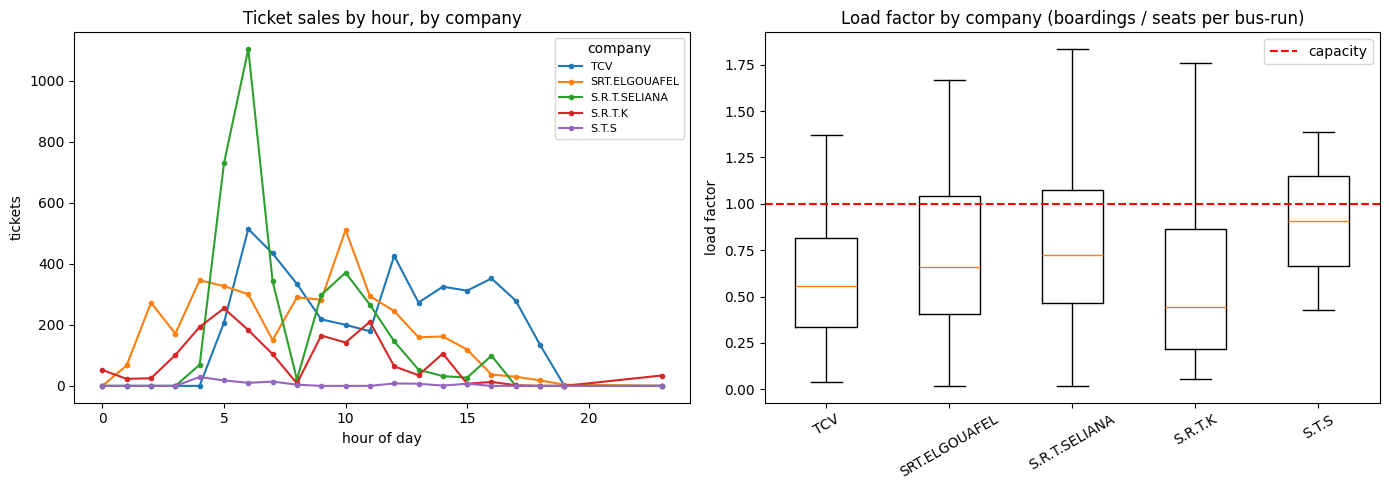

,bus_runs,mean_load,median_load,over_capacity,pct_over_capacity
societe,,,,,
S.T.S,2,0.91,0.91,1,50.0
S.R.T.SELIANA,81,0.81,0.72,25,31.0
SRT.ELGOUAFEL,94,0.75,0.66,24,26.0
TCV,262,0.59,0.56,28,11.0
S.R.T.K,56,0.57,0.44,10,18.0


In [22]:
# split BY COMPANY 
companies = tk.dropna(subset=["societe"])["societe"].value_counts().index.tolist()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ticket sales by hour, one line per company
by_hour = (tk.dropna(subset=["societe"]).groupby(["hour", "societe"]).size()
             .unstack(fill_value=0)[companies])
by_hour.plot(ax=ax[0], marker="o", ms=3)
ax[0].set_title("Ticket sales by hour, by company")
ax[0].set_xlabel("hour of day"); ax[0].set_ylabel("tickets")
ax[0].legend(title="company", fontsize=8)

# load-factor distribution per company (overcrowding proxy)
trip_c = trip.dropna(subset=["societe"])
data = [trip_c.loc[trip_c["societe"] == s, "load_factor"].values for s in companies]
ax[1].boxplot(data, labels=companies, showfliers=False)
ax[1].axhline(1.0, color="red", ls="--", label="capacity")
ax[1].set_title("Load factor by company (boardings / seats per bus-run)")
ax[1].set_ylabel("load factor"); ax[1].tick_params(axis="x", rotation=30); ax[1].legend()
plt.tight_layout(); plt.show()

# per-company summary table
summary = (trip_c.groupby("societe")
           .agg(bus_runs=("load_factor", "size"),
                mean_load=("load_factor", "mean"),
                median_load=("load_factor", "median"),
                over_capacity=("load_factor", lambda s: int((s > 1).sum())))
           .round(2)
           .sort_values("mean_load", ascending=False))
summary["pct_over_capacity"] = (100 * summary["over_capacity"] / summary["bus_runs"]).round(0)
display(summary)

### Breakdowns (`panne`) — short and unlabeled, but usable as weak anomaly labels

Only ~5 months, concentrated Apr–Jun 2026, and `type` is almost always blank. Still, the
**timestamps + bus ids** are real positive examples: we can cross-reference each breakdown
against the GPS track of that bus to validate a "bus stopped / abnormal" detector.

panne rows: 453 | range: 2026-01-24 11:02:00 -> 2026-06-22 13:44:00 | 'type' filled: 1 of 453


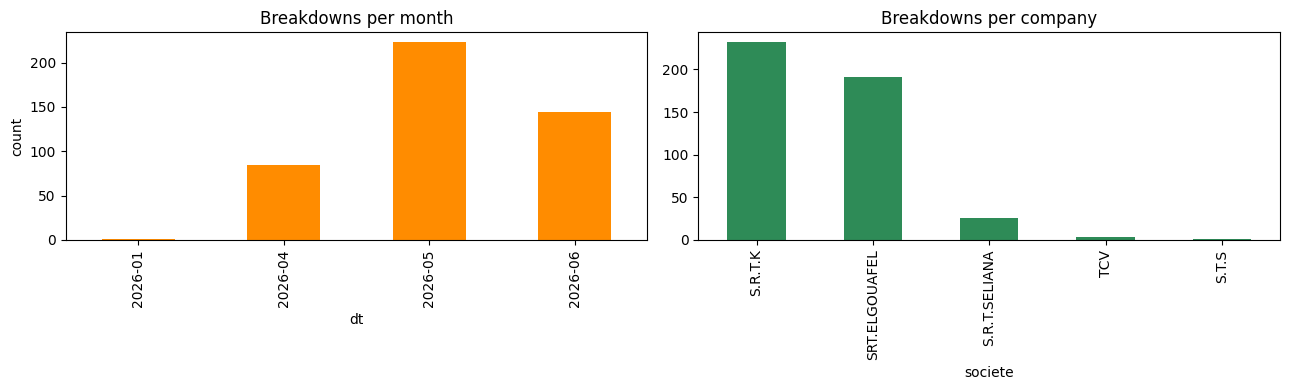

In [23]:
pn = pd.DataFrame(list(db_winicari["panne"].find({}, {"_id": 0})))
pn["dt"] = pd.to_datetime(pn["date"] + pn["heur"].str.zfill(4), format="%Y%m%d%H%M", errors="coerce")
bus2soc = {str(b["code"]): b.get("societe") for b in db_winicari["bus"].find({}, {"code": 1, "societe": 1})}
pn["societe"] = pn["bus"].astype(str).map(bus2soc)
print("panne rows:", len(pn), "| range:", pn["dt"].min(), "->", pn["dt"].max(),
      "| 'type' filled:", int((pn["type"].str.strip() != "").sum()), "of", len(pn))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
pn["dt"].dt.to_period("M").astype(str).value_counts().sort_index().plot(kind="bar", ax=ax[0], color="darkorange")
ax[0].set_title("Breakdowns per month"); ax[0].set_ylabel("count")
pn["societe"].value_counts(dropna=False).plot(kind="bar", ax=ax[1], color="seagreen")
ax[1].set_title("Breakdowns per company")
plt.tight_layout(); plt.show()